This notebook handles data cleaning and preprocessing.

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
file = pd.read_csv(r"C:\Users\grahu\Desktop\screensense\screensense\data\processed\Preprocessed_data.csv")

In [48]:
df=pd.DataFrame(file)
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Moderate
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,10-13,High
2,18,Female,3.73,Tv,True,0.32,Poor Sleep,Urban,18+,Moderate
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,14-17,Low
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High


Distrubution of avg screen time

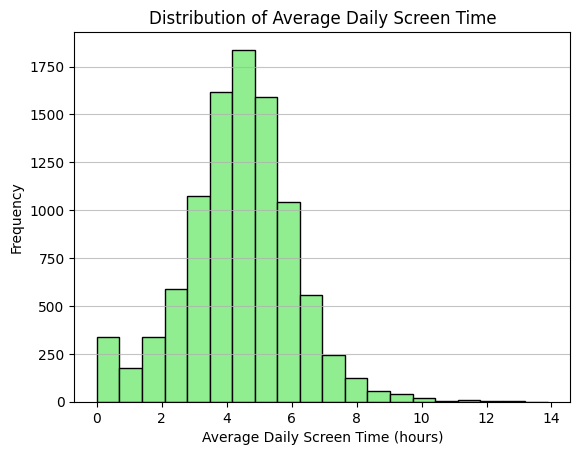

In [49]:
plt.figure()
plt.hist(df['Avg_Daily_Screen_Time_hr'], bins=20, edgecolor='black',color='lightgreen')
plt.xlabel('Average Daily Screen Time (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Average Daily Screen Time')
plt.grid(axis='y', alpha=0.75)
plt.show()

Age band distrubution

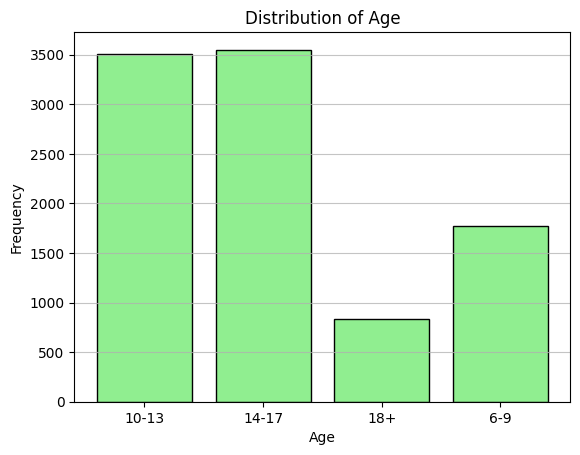

In [50]:
age_counts = df['Age_Band'].value_counts().sort_index()
plt.figure()
plt.bar(age_counts.index.astype(str), age_counts.values, color='lightgreen', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

Distrubution of Device Type 

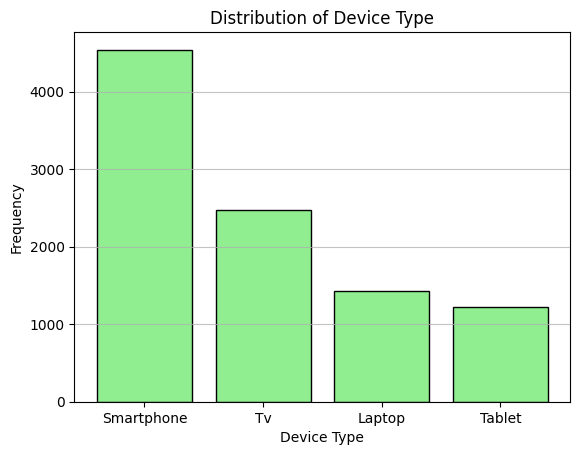

In [51]:
device_counts = df['Primary_Device'].value_counts()
plt.figure()
plt.bar(device_counts.index, device_counts.values, color='lightgreen', edgecolor='black')
plt.xlabel('Device Type')
plt.ylabel('Frequency')
plt.title('Distribution of Device Type')
plt.grid(axis='y', alpha=0.75)
plt.show()

Screen time by gender

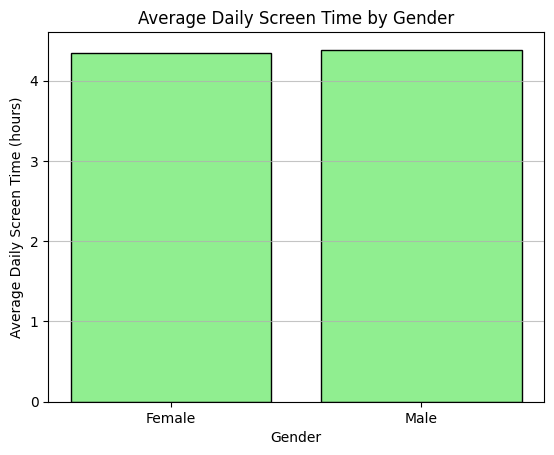

In [52]:
gender_avg=df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure()
plt.bar(gender_avg.index, gender_avg.values, color='lightgreen', edgecolor='black')
plt.xlabel('Gender')
plt.ylabel('Average Daily Screen Time (hours)') 
plt.title('Average Daily Screen Time by Gender')
plt.grid(axis='y', alpha=0.75)
plt.show()

Screen time by age 

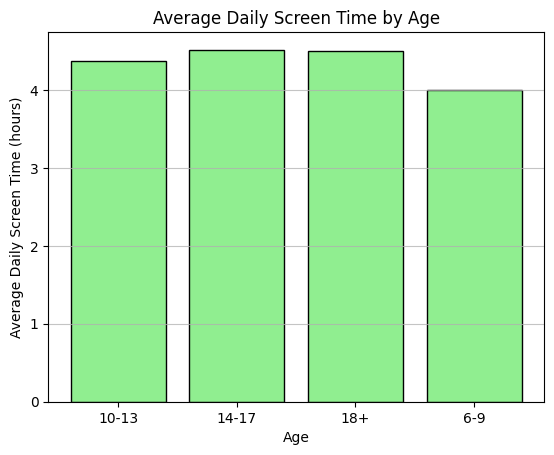

In [53]:
avg_age=df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()
plt.figure()
plt.bar(avg_age.index.astype(str), avg_age.values, color='lightgreen', edgecolor='black')
age_order=['6-9', '10-13', '14-17', '18+']
plt.xlabel('Age')
plt.ylabel('Average Daily Screen Time (hours)')
plt.title('Average Daily Screen Time by Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

Univariate and Bivariate analysis

distubution of daily screen time

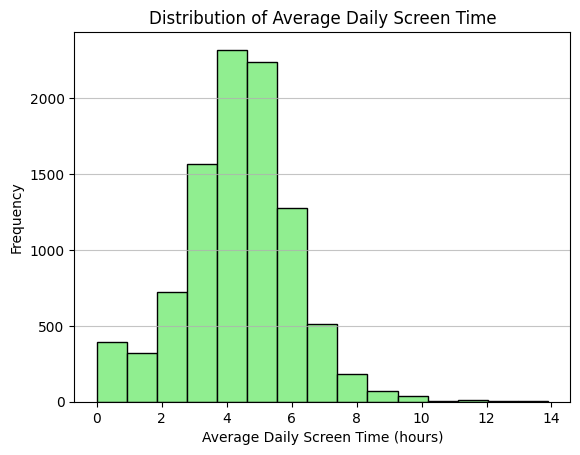

In [54]:
plt.figure()
plt.hist(df['Avg_Daily_Screen_Time_hr'], bins=15, edgecolor='black', color='lightgreen')
plt.xlabel('Average Daily Screen Time (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Average Daily Screen Time')
plt.grid(axis='y', alpha=0.75)
plt.show()



Age band distrubution

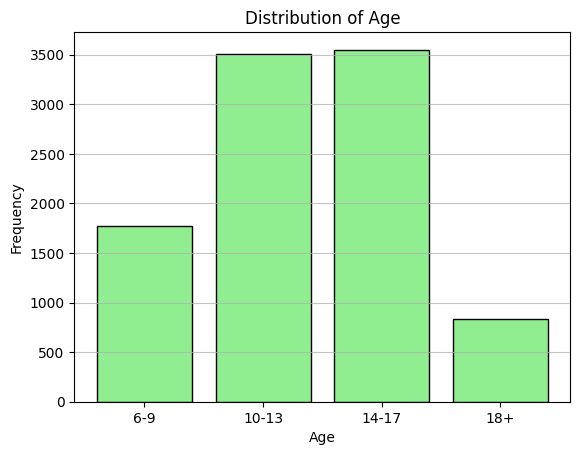

In [55]:
age_order=['6-9', '10-13', '14-17', '18+']
df['Age_Band'] = pd.Categorical(df['Age_Band'], categories=age_order, ordered=True)
age_counts = df['Age_Band'].value_counts().sort_index()
plt.figure()
plt.bar(age_counts.index.astype(str), age_counts.values, color='lightgreen', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

Device distrubution type analysis

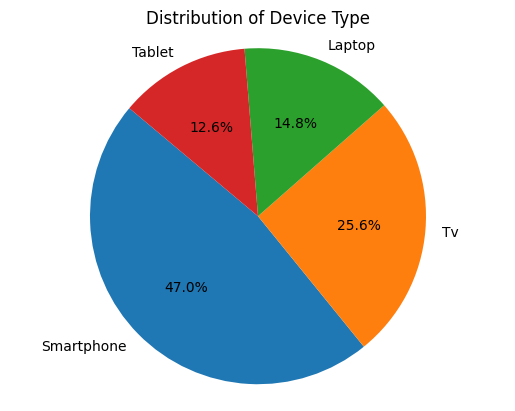

In [56]:
device_counts = df['Primary_Device'].value_counts()
plt.figure()
plt.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',  startangle=140)
plt.title('Distribution of Device Type')
plt.axis('equal')
plt.show()


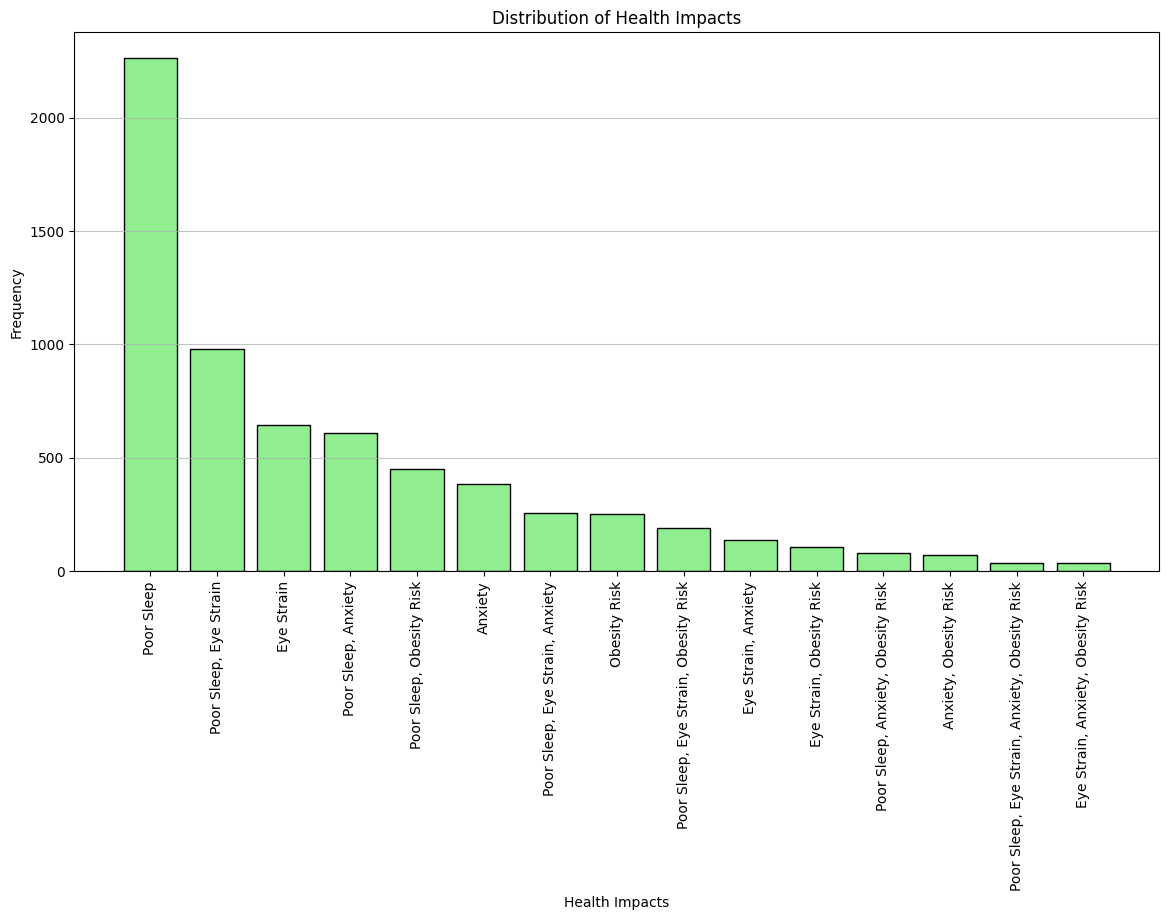

In [57]:
plt.show()

# Distribution of Health Impacts
health_counts = df['Health_Impacts'].value_counts()
plt.figure(figsize=(14, 7)) # Making the figure slightly wider for readability
plt.bar(health_counts.index, health_counts.values, color='lightgreen', edgecolor='black')
plt.xlabel('Health Impacts')
plt.ylabel('Frequency')
plt.title('Distribution of Health Impacts')
plt.xticks(rotation=90) # Rotates labels so they don't overlap
plt.grid(axis='y', alpha=0.75)
plt.show()

multivaiate analysis

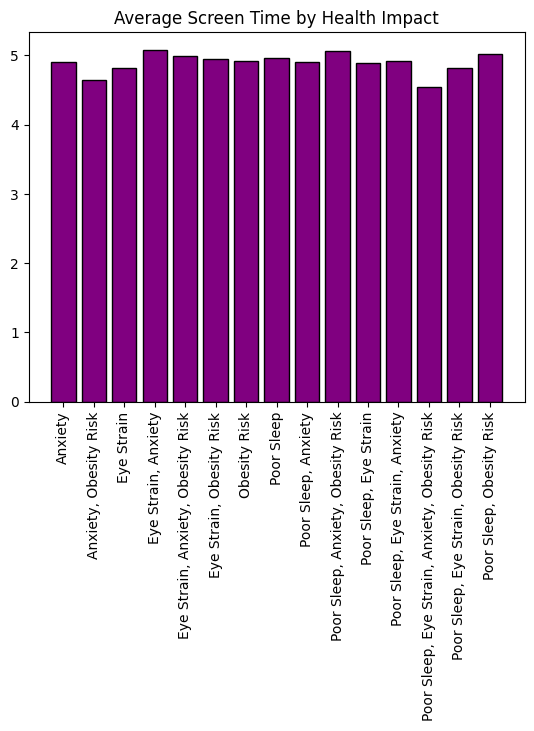

In [58]:
health_avg = df.groupby('Health_Impacts')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure()
plt.bar(health_avg.index, health_avg.values, color='purple', edgecolor='black')

plt.xticks(rotation=90)
plt.title("Average Screen Time by Health Impact")

plt.show()

In [59]:
pivot_table = pd.pivot_table(
    df,
    values='Avg_Daily_Screen_Time_hr',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

print(pivot_table)

Primary_Device    Laptop  Smartphone    Tablet        Tv
Age_Band                                                
6-9                  NaN    3.971674  4.015066  4.031487
10-13           4.432627    4.444612  4.205660  4.269798
14-17           4.466245    4.531242  4.485863  4.543711
18+             4.515500    4.515366  4.483125  4.467216


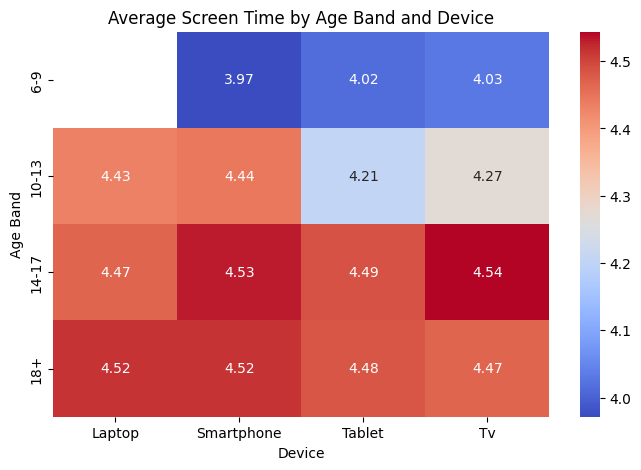

In [60]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Average Screen Time by Age Band and Device")
plt.xlabel("Device")
plt.ylabel("Age Band")

plt.show()

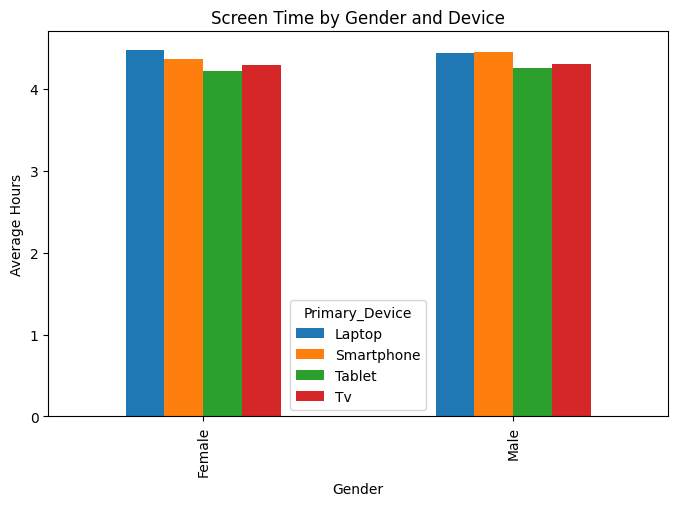

In [61]:
gender_device = df.groupby(
    ['Gender','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean().unstack()

gender_device.plot(kind='bar', figsize=(8,5))

plt.title("Screen Time by Gender and Device")
plt.ylabel("Average Hours")

plt.show()

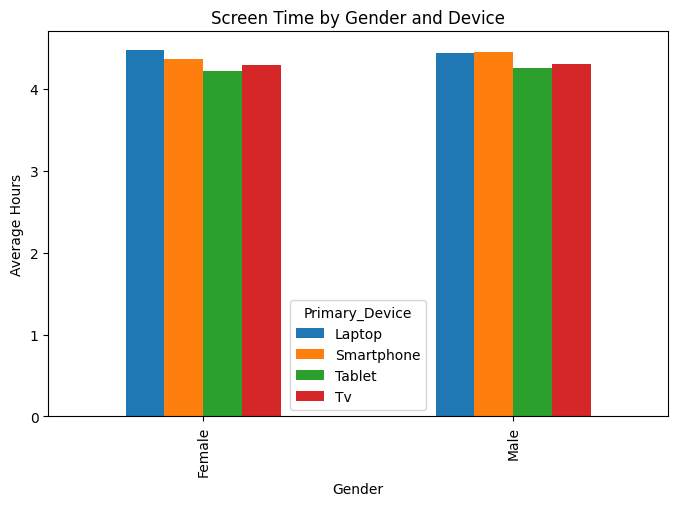

In [62]:
gender_device = df.groupby(
    ['Gender','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean().unstack()

gender_device.plot(kind='bar', figsize=(8,5))

plt.title("Screen Time by Gender and Device")
plt.ylabel("Average Hours")

plt.show()

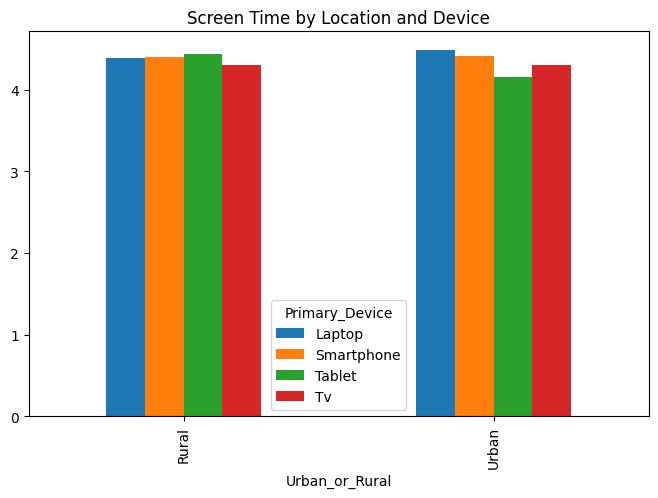

In [63]:
location_device = df.groupby(
    ['Urban_or_Rural','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean().unstack()

location_device.plot(kind='bar', figsize=(8,5))

plt.title("Screen Time by Location and Device")

plt.show()

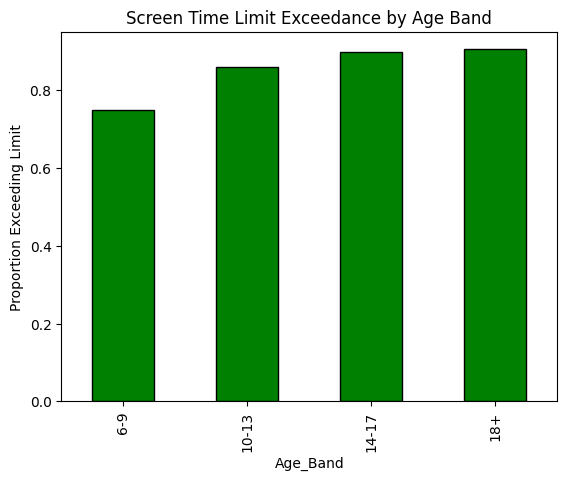

In [64]:
limit_exceed = df.groupby('Age_Band')['Exceeded_Recommended_Limit'].mean()

plt.figure()
limit_exceed.plot(kind='bar', color='green', edgecolor='black')

plt.title("Screen Time Limit Exceedance by Age Band")
plt.ylabel("Proportion Exceeding Limit")

plt.show()

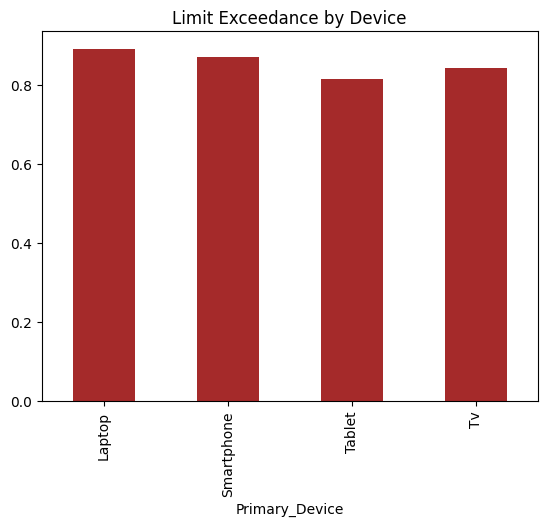

In [65]:
device_limit = df.groupby('Primary_Device')['Exceeded_Recommended_Limit'].mean()

plt.figure()
device_limit.plot(kind='bar', color='brown')

plt.title("Limit Exceedance by Device")

plt.show()

In [66]:
cohort = df.groupby(
    ['Age_Band','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean()

print(cohort.sort_values(ascending=False).head(10))

Age_Band  Primary_Device
14-17     Tv                4.543711
          Smartphone        4.531242
18+       Laptop            4.515500
          Smartphone        4.515366
14-17     Tablet            4.485863
18+       Tablet            4.483125
          Tv                4.467216
14-17     Laptop            4.466245
10-13     Smartphone        4.444612
          Laptop            4.432627
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [67]:
df.to_csv("screensense_cleaned.csv", index=False)

In [68]:
df.to_csv("screensense_cleaned.csv", index=False)

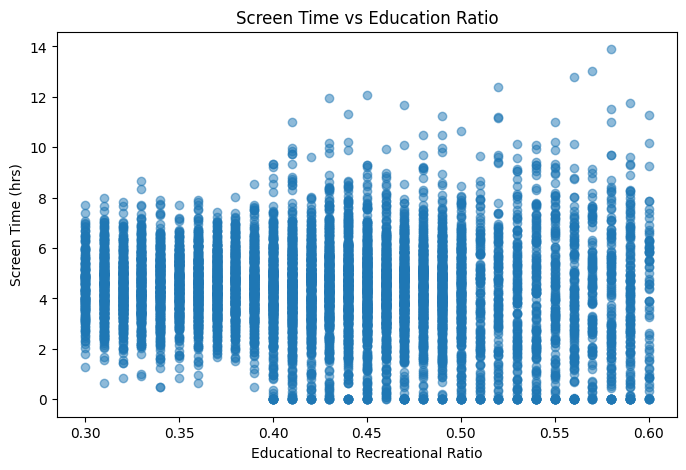

In [69]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Educational_to_Recreational_Ratio'],
    df['Avg_Daily_Screen_Time_hr'],
    alpha=0.5
)

plt.xlabel("Educational to Recreational Ratio")
plt.ylabel("Screen Time (hrs)")
plt.title("Screen Time vs Education Ratio")

plt.show()

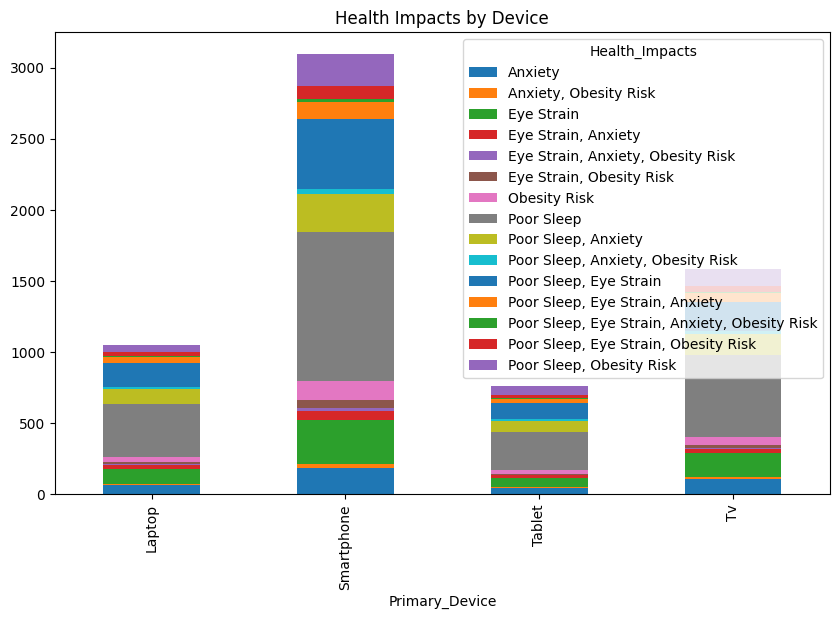

In [70]:
health_device = df.groupby(
    ['Primary_Device','Health_Impacts']
).size().unstack()

health_device.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Health Impacts by Device")

plt.show()

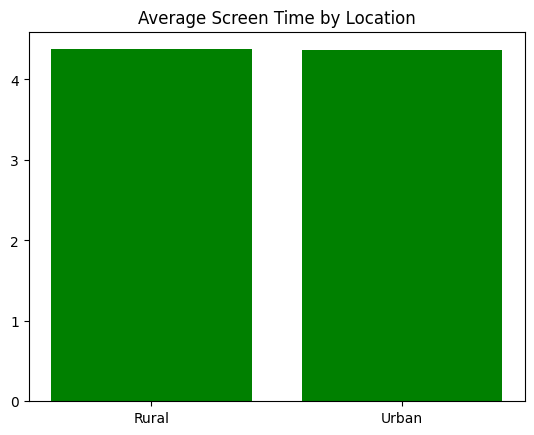

In [71]:
location_avg = df.groupby(
    'Urban_or_Rural'
)['Avg_Daily_Screen_Time_hr'].mean()

plt.figure()

plt.bar(
    location_avg.index,
    location_avg.values,
    color='green'
)

plt.title("Average Screen Time by Location")

plt.show()

In [72]:
import seaborn as sns

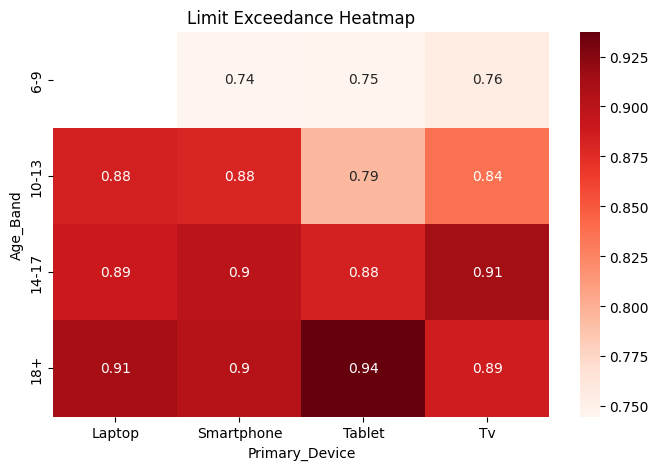

In [73]:
pivot_limit = pd.pivot_table(
    df,
    values='Exceeded_Recommended_Limit',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_limit,
    annot=True,
    cmap="Reds"
)

plt.title("Limit Exceedance Heatmap")

plt.show()

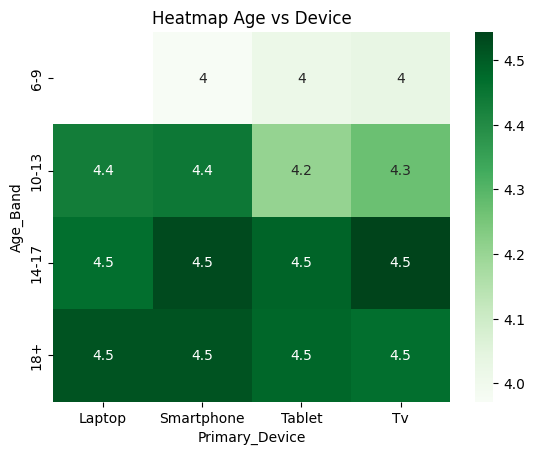

In [74]:
import seaborn as sns

pivot = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='Greens')
plt.title("Heatmap Age vs Device")
plt.show()

In [75]:
risk = df.groupby(
    ['Age_Band','Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean()

risk.sort_values(ascending=False).head(10)

Age_Band  Primary_Device
14-17     Tv                4.543711
          Smartphone        4.531242
18+       Laptop            4.515500
          Smartphone        4.515366
14-17     Tablet            4.485863
18+       Tablet            4.483125
          Tv                4.467216
14-17     Laptop            4.466245
10-13     Smartphone        4.444612
          Laptop            4.432627
Name: Avg_Daily_Screen_Time_hr, dtype: float64

In [76]:
cohort_age = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()
print(cohort_age)

cohort_device = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean()
print(cohort_device)

cohort_location = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean()
print(cohort_location)

Age_Band
6-9      4.003820
10-13    4.369386
14-17    4.516362
18+      4.502217
Name: Avg_Daily_Screen_Time_hr, dtype: float64
Primary_Device
Laptop        4.458784
Smartphone    4.410154
Tablet        4.241846
Tv            4.299544
Name: Avg_Daily_Screen_Time_hr, dtype: float64
Urban_or_Rural
Rural    4.375640
Urban    4.364482
Name: Avg_Daily_Screen_Time_hr, dtype: float64


In [77]:
cohort1 = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

print(cohort1)

Primary_Device    Laptop  Smartphone    Tablet        Tv
Age_Band                                                
6-9                  NaN    3.971674  4.015066  4.031487
10-13           4.432627    4.444612  4.205660  4.269798
14-17           4.466245    4.531242  4.485863  4.543711
18+             4.515500    4.515366  4.483125  4.467216


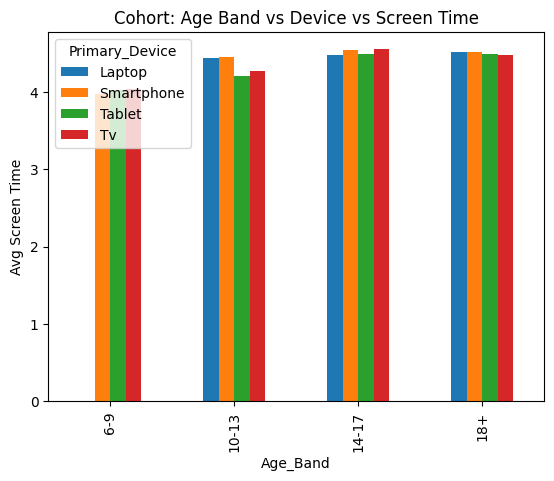

In [78]:
cohort1.plot(kind='bar')
plt.title("Cohort: Age Band vs Device vs Screen Time")
plt.ylabel("Avg Screen Time")
plt.show()

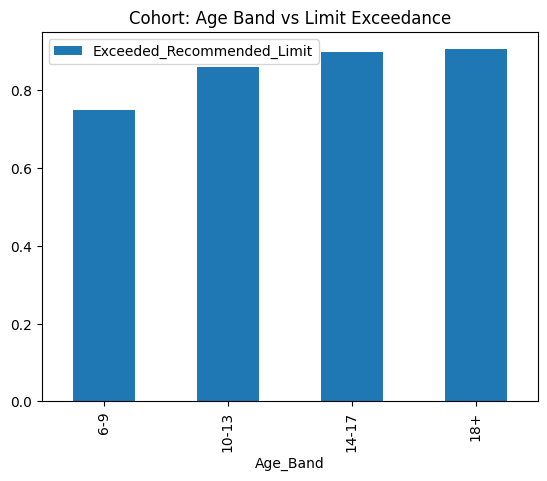

In [79]:
cohort2 = df.pivot_table(
    values='Exceeded_Recommended_Limit',
    index='Age_Band',
    aggfunc='mean'
)

cohort2.plot(kind='bar')
plt.title("Cohort: Age Band vs Limit Exceedance")
plt.show()

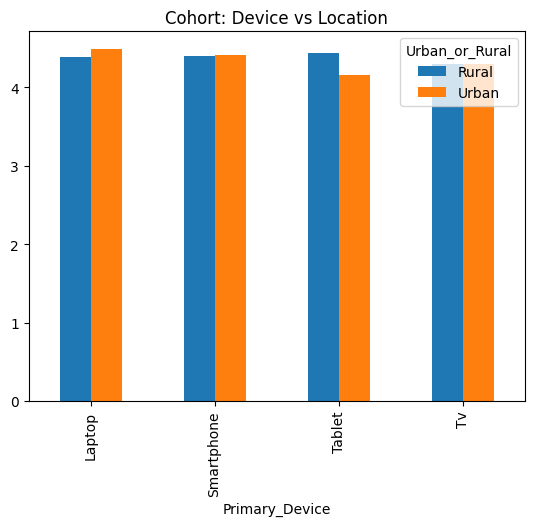

In [80]:
cohort3 = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Primary_Device',
    columns='Urban_or_Rural',
    aggfunc='mean'
)

cohort3.plot(kind='bar')
plt.title("Cohort: Device vs Location")
plt.show()

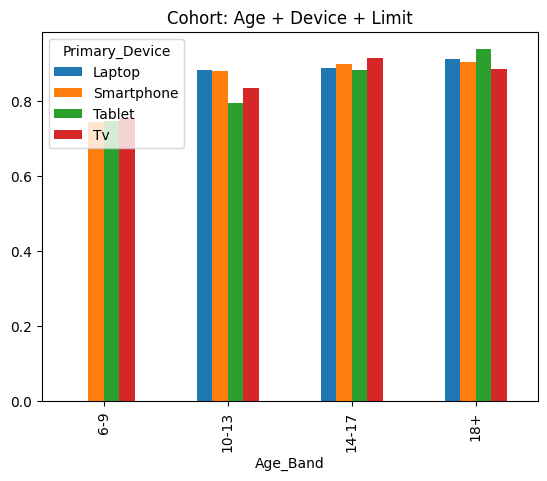

In [81]:
cohort4 = df.pivot_table(
    values='Exceeded_Recommended_Limit',
    index='Age_Band',
    columns='Primary_Device',
    aggfunc='mean'
)

cohort4.plot(kind='bar')
plt.title("Cohort: Age + Device + Limit")
plt.show()

In [82]:
risk = df.groupby(
    ['Age_Band', 'Primary_Device']
)['Avg_Daily_Screen_Time_hr'].mean()

risk = risk.sort_values(ascending=False)

risk.head(10)

Age_Band  Primary_Device
14-17     Tv                4.543711
          Smartphone        4.531242
18+       Laptop            4.515500
          Smartphone        4.515366
14-17     Tablet            4.485863
18+       Tablet            4.483125
          Tv                4.467216
14-17     Laptop            4.466245
10-13     Smartphone        4.444612
          Laptop            4.432627
Name: Avg_Daily_Screen_Time_hr, dtype: float64

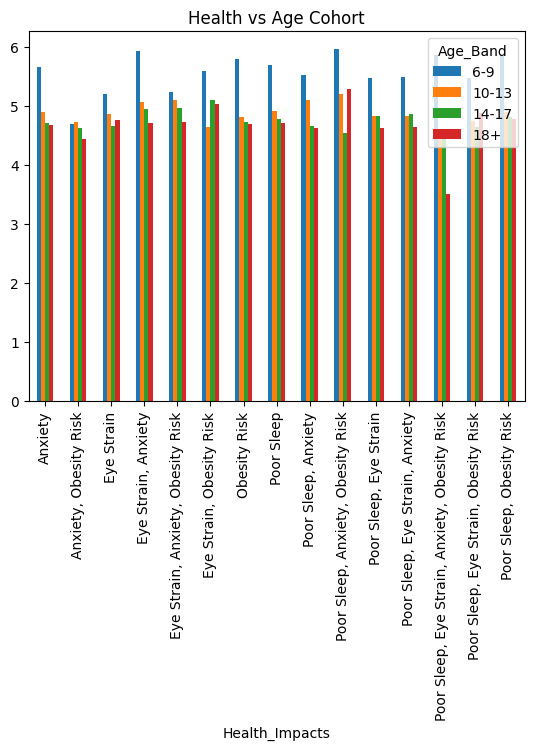

In [83]:
cohort5 = df.pivot_table(
    values='Avg_Daily_Screen_Time_hr',
    index='Health_Impacts',
    columns='Age_Band',
    aggfunc='mean'
)

cohort5.plot(kind='bar')
plt.title("Health vs Age Cohort")
plt.show()